In [1]:
import pandas as pd

df = pd.read_csv('./Data/syriatel_data.csv')

df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

The data contains no empty cells. No imputation is needed.

Objective: Build a classifier to predict whether a customer will ("soon") stop doing business with SyriaTel, a telecommunications company

Columns of interest:

`state`: The US state where the customer resides (represented by a 2-letter abbreviation, e.g., KS for Kansas, OH for Ohio).
'account length': The number of days the customer has had an active account with the company.

`phone number`: The customer's 7-digit phone number. In this dataset, it essentially acts as a unique identifier for the customer.

`international plan`: A binary feature (yes or no) indicating whether the customer pays for an international calling plan.

`voice mail plan`: A binary feature (yes or no) indicating whether the customer pays for a voicemail plan.

`total [time] minutes`: The total number of minutes the customer spent on calls during that specific time (day, evening, night, international) period.

`total [time] calls`: The total count of individual phone calls the customer made/received during that time period.

`total [time] charge`: The monetary amount the telecom company billed the customer for that specific usage

`customer service calls`: The number of times the customer has called the telecom's customer service/support line. High numbers here are often a strong indicator of customer frustration.

`churn`: This is usually your target variable. A boolean feature (True or False) indicating whether the customer ultimately cancelled their service ("churned") or stayed with the company.

Other columns:

`area code`: The 3-digit area code of the customer's phone number

`number vmail messages`: The number of voicemail messages the customer currently has. (If they don't have a voicemail plan, this number is usually 0)

More information about the columns is located in [SyriaTel_Dataset_Feature_Dictionary](./Data/SyriaTel_Dataset_Feature_Dictionary.txt)

I will do some feature engineering on the boolean columns `churn`, `international plan` and `voice mail plan` to convert them to easy-to-work-with integers

In [3]:
# Convert boolean churn to 1 and 0
df['churn'] = df['churn'].astype(int)

# Convert 'yes'/'no' string columns to 1 and 0
df['international plan'] = df['international plan'].map({'yes': 1, 'no': 0})
df['voice mail plan'] = df['voice mail plan'].map({'yes': 1, 'no': 0})

df[['international plan', 'voice mail plan', 'churn']].head()

,international plan,voice mail plan,churn
0,0,1,0
1,0,1,0
2,0,0,0
3,1,0,0
4,1,0,0


I will see how `churn` correlates with the other numeric columns

In [4]:
# I will do it on a copy to prevent destroying the original
df_corr = df.copy()

# Drop non-numeric and irrelevant columns
df_corr_numeric = df_corr.drop(columns=['state', 'phone number'])

# Calculate the correlation and sort it
churn_corr = df_corr_numeric.corr()['churn'].sort_values(ascending=False)

churn_corr

churn                     1.000000
international plan        0.259852
customer service calls    0.208750
total day minutes         0.205151
total day charge          0.205151
total eve minutes         0.092796
total eve charge          0.092786
total intl charge         0.068259
total intl minutes        0.068239
total night charge        0.035496
total night minutes       0.035493
total day calls           0.018459
account length            0.016541
total eve calls           0.009233
area code                 0.006174
total night calls         0.006141
total intl calls         -0.052844
number vmail messages    -0.089728
voice mail plan          -0.102148
Name: churn, dtype: float64

As can be seen churn is most positively correlated with whether or not the user has an international plan and most negatively correlated with whether or not the user had a voice mail plan

I will visualize the number of people with international plans who churned and didn't churn

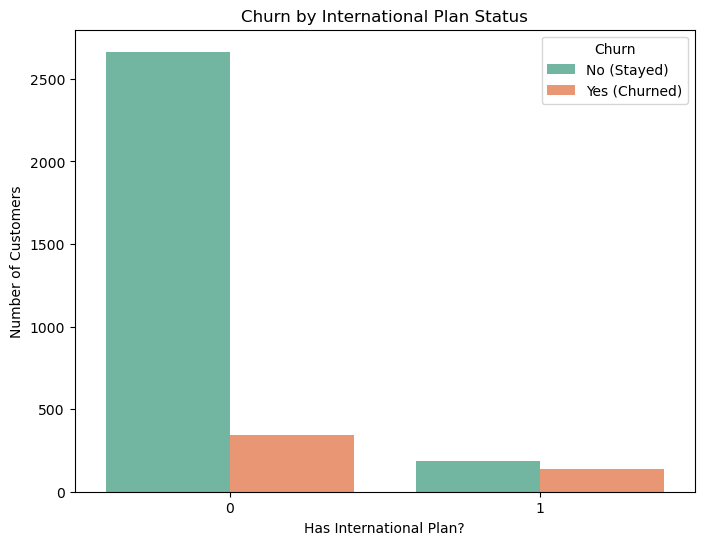

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size
plt.figure(figsize=(8, 6))

# Create a countplot
# x puts 'international plan' categories on the bottom axis
# hue splits the bars based on 'churn' status
sns.countplot(data=df, x='international plan', hue='churn', palette='Set2')

# Add clear labels and a title
plt.title('Churn by International Plan Status')
plt.xlabel('Has International Plan?')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No (Stayed)', 'Yes (Churned)'])

# Display the plot
plt.show()